In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

In [6]:
data=load_diabetes()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target

In [7]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [9]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [11]:
df.shape

(442, 11)

In [12]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
437    False
438    False
439    False
440    False
441    False
Length: 442, dtype: bool

In [24]:
#removing outliers
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
iqr=Q3-Q1
lower_bound=Q1- (1.5*iqr)
upper_bound=Q3+(1.5*iqr)
df_cleaned=df[~((df<= lower_bound) | (df>= upper_bound)).any(axis=1)]

In [25]:
df_cleaned.shape


(409, 11)

<Axes: >

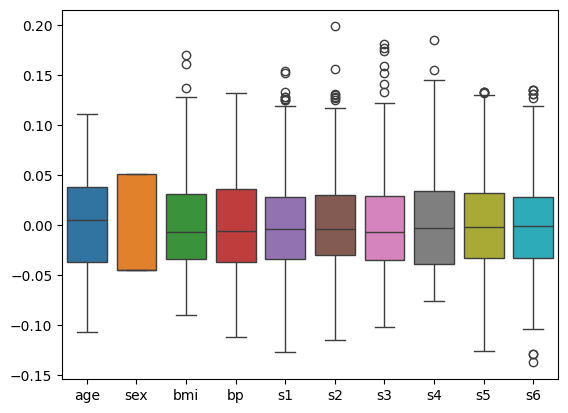

In [26]:
#boxplot
sns.boxplot(df.drop(columns=['target']))

<Axes: >

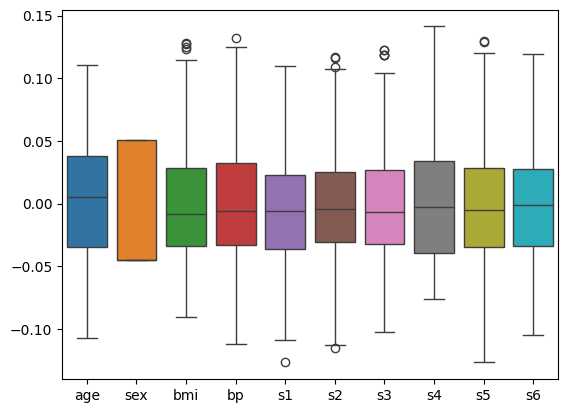

In [27]:
#boxplot
sns.boxplot(df_cleaned.drop(columns=['target']))

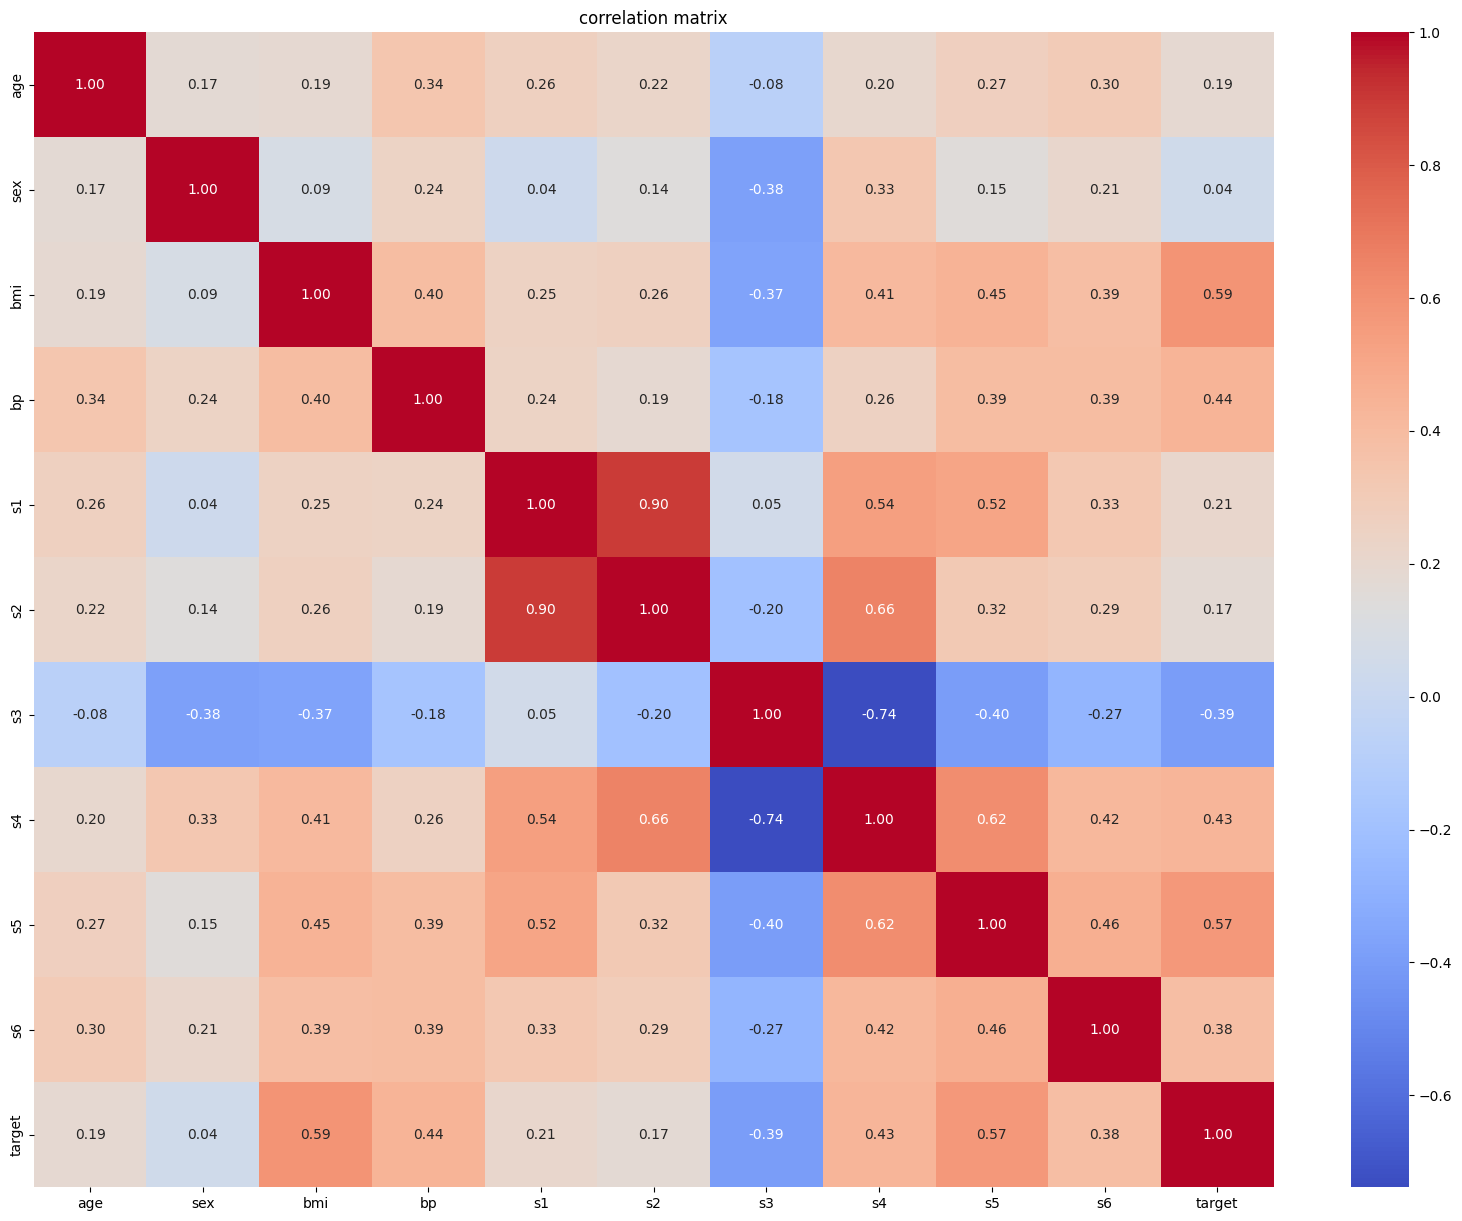

In [29]:
#correlation metrix
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation matrix')
plt.show()

In [45]:
x=df_cleaned.drop(columns=['target'], axis=1)
y=df_cleaned['target']

In [46]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)

In [47]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [48]:
model_linear=LinearRegression()
model_linear.fit(x_train_scaled, y_train)
y_pred=model_linear.predict(x_test_scaled)

In [49]:
print("r2_score: ", r2_score(y_test, y_pred))
print("mean squared error: ", mean_squared_error(y_test, y_pred))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("root mean squared error: ", root_mean_squared_error(y_test, y_pred))


r2_score:  0.5661550942642911
mean squared error:  3035.1843803622487
mean absolute error:  42.30351541081631
root mean squared error:  55.09250747935012


In [50]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_scaled)
x_test_poly=poly.transform(x_test_scaled)

In [51]:
model_poly=LinearRegression()
model_poly.fit(x_train_poly, y_train)
y_pred_poly=model_poly.predict(x_test_poly)

In [52]:
print("r2_score: ", r2_score(y_test, y_pred_poly))
print("mean squared error: ", mean_squared_error(y_test, y_pred_poly))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred_poly))
print("root mean squared error: ", root_mean_squared_error(y_test, y_pred_poly))


r2_score:  0.49383090412194774
mean squared error:  3541.1653181126535
mean absolute error:  48.246184248055314
root mean squared error:  59.50769125174202


In [53]:
ridge_model=Ridge(alpha=1.0)
ridge_model.fit(x_train_scaled, y_train)
y_pred_ridge=ridge_model.predict(x_test_scaled)

In [54]:
print("r2_score: ", r2_score(y_test, y_pred_ridge))
print("mean squared error: ", mean_squared_error(y_test, y_pred_ridge))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred_ridge))
print("root mean squared error: ", root_mean_squared_error(y_test, y_pred_ridge))

r2_score:  0.5664273649249632
mean squared error:  3033.2795714188287
mean absolute error:  42.29064030604129
root mean squared error:  55.07521739783538


In [55]:
ridge_poly=Ridge(alpha=1.0)
ridge_poly.fit(x_train_poly, y_train)
y_pred_ridge=ridge_poly.predict(x_test_poly)

In [56]:
print("r2_score: ", r2_score(y_test, y_pred_ridge))
print("mean squared error: ", mean_squared_error(y_test, y_pred_ridge))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred_ridge))
print("root mean squared error: ", root_mean_squared_error(y_test, y_pred_ridge))

r2_score:  0.4662511695483612
mean squared error:  3734.113485731063
mean absolute error:  48.662654802843726
root mean squared error:  61.107393052977336


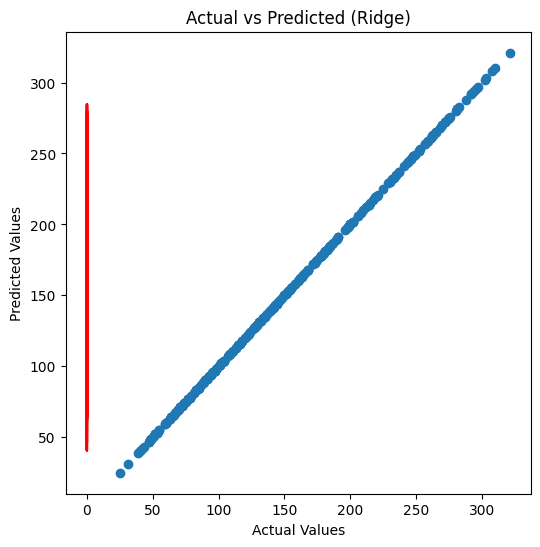

In [63]:
plt.figure(figsize=(6,6))
plt.scatter(y_train, y_train)

# perfect prediction line
plt.plot(
    x_train, model_linear.predict(x_train_scaled),
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Ridge)")
plt.show()

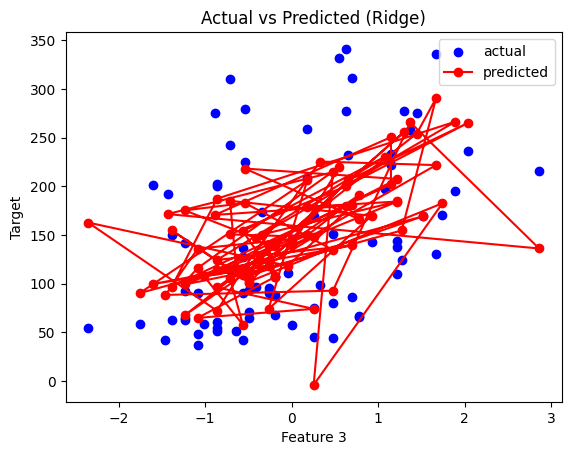

In [66]:
plt.scatter(x_test_scaled[:, 3], y_test, color='blue', label='actual')
plt.plot(x_test_scaled[:, 3], y_pred_ridge, color='red', label='predicted', marker='o')
plt.xlabel("Feature 3")
plt.ylabel("Target")
plt.title("Actual vs Predicted (Ridge)")
plt.legend()